In [1]:
# Wildlife Observation Dataset Analysis
# Complete Notebook with EDA, Visualizations, and Predictive Modeling

## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

## dataset overview

### the dataset

In [3]:
df = pd.read_csv("/kaggle/input/global-crocodile-species-dataset/crocodile_dataset.csv")

print("✅ Dataset Generated Successfully!")
print(f"Shape: {df.shape}")
print("\nColumn Information:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())
print("\n" + "="*50)
print("📊 PHASE 1: DATASET OVERVIEW")
print("="*50)

✅ Dataset Generated Successfully!
Shape: (1000, 15)

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Observation ID        1000 non-null   int64  
 1   Common Name           1000 non-null   object 
 2   Scientific Name       1000 non-null   object 
 3   Family                1000 non-null   object 
 4   Genus                 1000 non-null   object 
 5   Observed Length (m)   1000 non-null   float64
 6   Observed Weight (kg)  1000 non-null   float64
 7   Age Class             1000 non-null   object 
 8   Sex                   1000 non-null   object 
 9   Date of Observation   1000 non-null   object 
 10  Country/Region        1000 non-null   object 
 11  Habitat Type          1000 non-null   object 
 12  Conservation Status   1000 non-null   object 
 13  Observer Name         1000 non-null   object 
 14  

### Basic statistics

In [4]:
print(f"Dataset Shape: {df.shape}")
print(f"Total Observations: {len(df)}")
print(f"Number of Features: {df.shape[1]}")

Dataset Shape: (1000, 15)
Total Observations: 1000
Number of Features: 15


### Missing values check


In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Observation ID          0
Common Name             0
Scientific Name         0
Family                  0
Genus                   0
Observed Length (m)     0
Observed Weight (kg)    0
Age Class               0
Sex                     0
Date of Observation     0
Country/Region          0
Habitat Type            0
Conservation Status     0
Observer Name           0
Notes                   0
dtype: int64


### Data types

In [6]:
print("\nData Types:")
print(df.dtypes)


Data Types:
Observation ID            int64
Common Name              object
Scientific Name          object
Family                   object
Genus                    object
Observed Length (m)     float64
Observed Weight (kg)    float64
Age Class                object
Sex                      object
Date of Observation      object
Country/Region           object
Habitat Type             object
Conservation Status      object
Observer Name            object
Notes                    object
dtype: object


### Summary statistics for numerical columns

In [7]:
# Summary statistics for numerical columns
numerical_cols = ['Observed Length (m)', 'Observed Weight (kg)']
print("\nSummary Statistics (Numerical Features):")
print(df[numerical_cols].describe())


Summary Statistics (Numerical Features):
       Observed Length (m)  Observed Weight (kg)
count          1000.000000           1000.000000
mean              2.415110            155.771900
std               1.097542            175.186788
min               0.140000              4.400000
25%               1.637500             53.225000
50%               2.430000            100.600000
75%               3.010000            168.875000
max               6.120000           1139.700000


### Categorical features summary

In [8]:
# Categorical features summary
categorical_cols = ['Common Name', 'Family', 'Age Class', 'Sex', 'Conservation Status', 'Habitat Type']
print("\nCategorical Features Summary:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Categorical Features Summary:

Common Name:
Common Name
New Guinea Crocodile                         68
Borneo Crocodile (disputed)                  67
American Crocodile                           66
Morelet's Crocodile                          64
Cuban Crocodile                              59
Saltwater Crocodile                          58
Philippine Crocodile                         58
Orinoco Crocodile                            58
West African Dwarf Crocodile                 57
Central African Slender-snouted Crocodile    56
West African Slender-snouted Crocodile       55
West African Crocodile                       52
Hall's New Guinea Crocodile                  49
Congo Dwarf Crocodile                        48
Nile Crocodile                               48
Mugger Crocodile (Marsh Crocodile)           47
Siamese Crocodile                            45
Freshwater Crocodile (Johnstone's)           45
Name: count, dtype: int64

Family:
Family
Crocodylidae    1000
Name: count, dty

## EXPLORATORY DATA ANALYSIS

In [9]:
print("\n" + "="*50)
print("🔍 PHASE 2: EXPLORATORY DATA ANALYSIS")
print("="*50)


🔍 PHASE 2: EXPLORATORY DATA ANALYSIS


### 1. Species Distribution

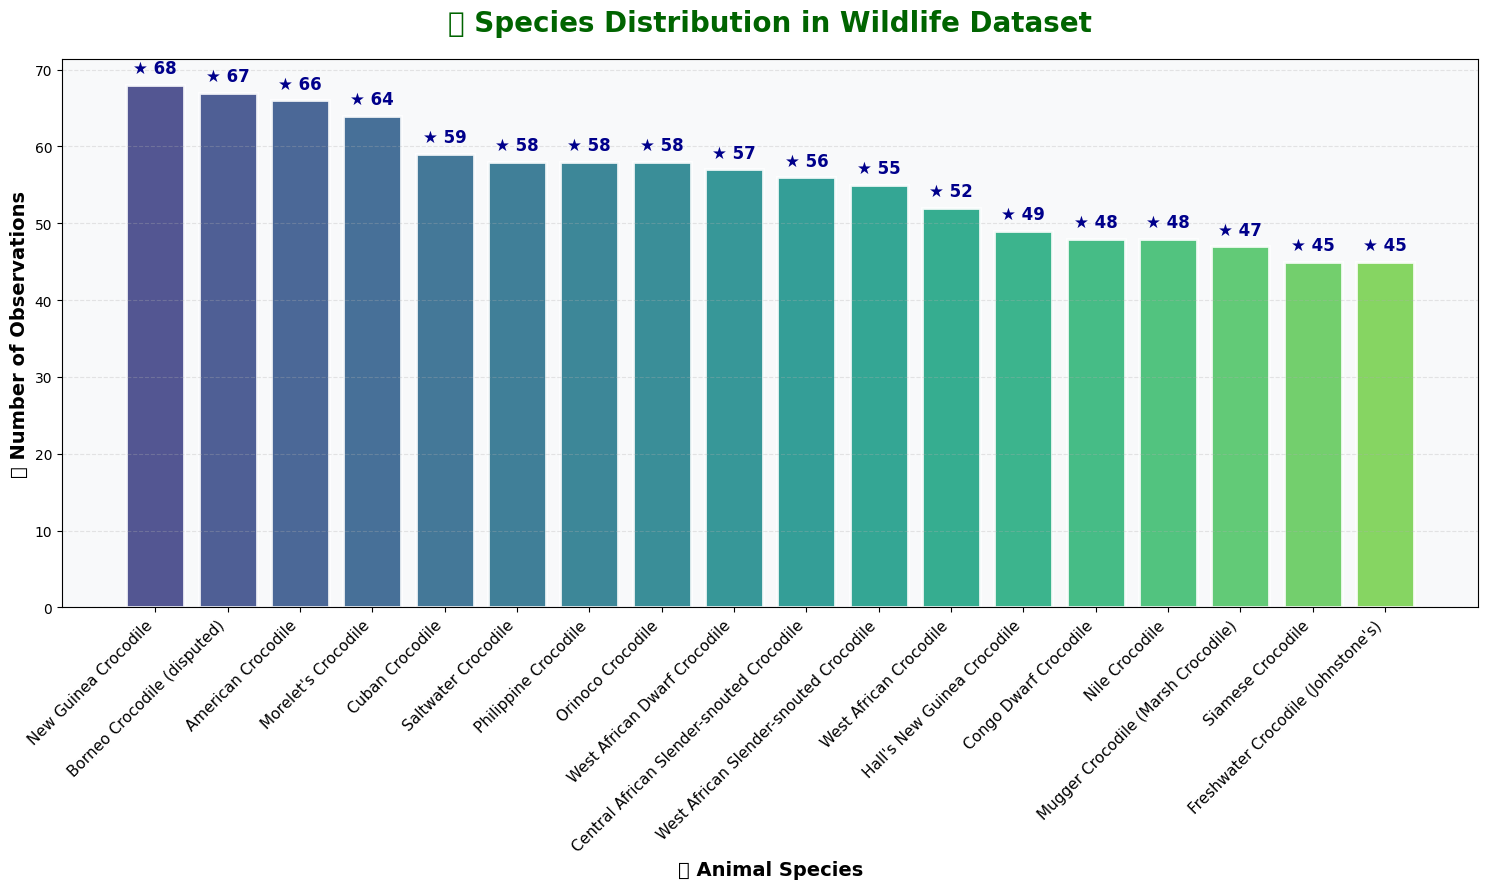

In [10]:
# 1. Species Distribution
plt.figure(figsize=(15, 9))
species_counts = df['Common Name'].value_counts()
# Create gradient colors
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(species_counts)))
bars = plt.bar(range(len(species_counts)), species_counts.values, 
               color=colors, edgecolor='white', linewidth=2, alpha=0.9)

# Add value labels on bars with star markers
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'★ {int(height)}', ha='center', va='bottom', 
             fontsize=12, fontweight='bold', color='darkblue')

plt.title('🦁 Species Distribution in Wildlife Dataset', 
          fontsize=20, fontweight='bold', color='darkgreen', pad=20)
plt.xlabel('🐾 Animal Species', fontsize=14, fontweight='bold')
plt.ylabel('📊 Number of Observations', fontsize=14, fontweight='bold')
plt.xticks(range(len(species_counts)), species_counts.index, 
           rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#f8f9fa')
plt.tight_layout()
plt.show()

### 2. Conservation Status Distribution

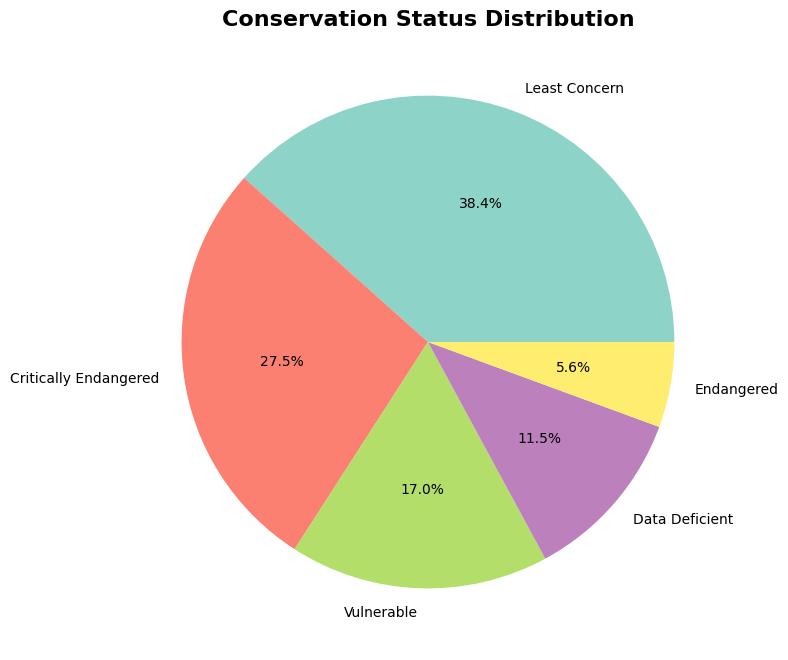

In [11]:
# 2. Conservation Status Distribution
plt.figure(figsize=(10, 8))
conservation_counts = df['Conservation Status'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(conservation_counts)))
plt.pie(conservation_counts.values, labels=conservation_counts.index, autopct='%1.1f%%', colors=colors)
plt.title('Conservation Status Distribution', fontsize=16, fontweight='bold')
plt.show()

### 3. Length vs Weight Scatter Plot

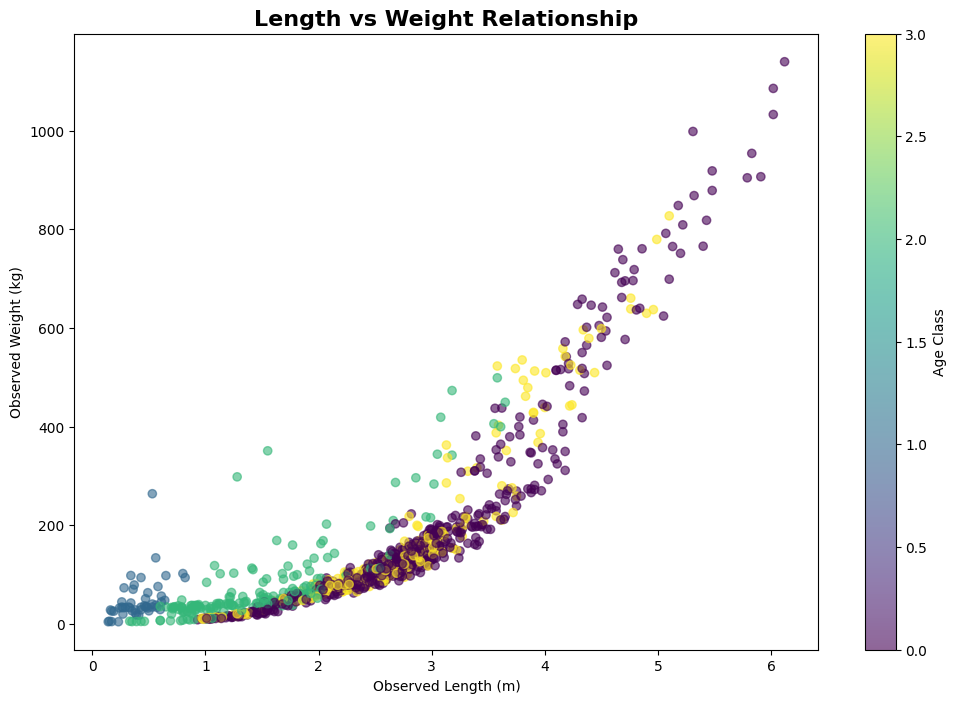

In [12]:
# 3. Length vs Weight Scatter Plot
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['Observed Length (m)'], df['Observed Weight (kg)'], 
                     c=pd.Categorical(df['Age Class']).codes, cmap='viridis', alpha=0.6)
plt.xlabel('Observed Length (m)')
plt.ylabel('Observed Weight (kg)')
plt.title('Length vs Weight Relationship', fontsize=16, fontweight='bold')
plt.colorbar(scatter, label='Age Class')
plt.show()

### 4. Age Class Distribution


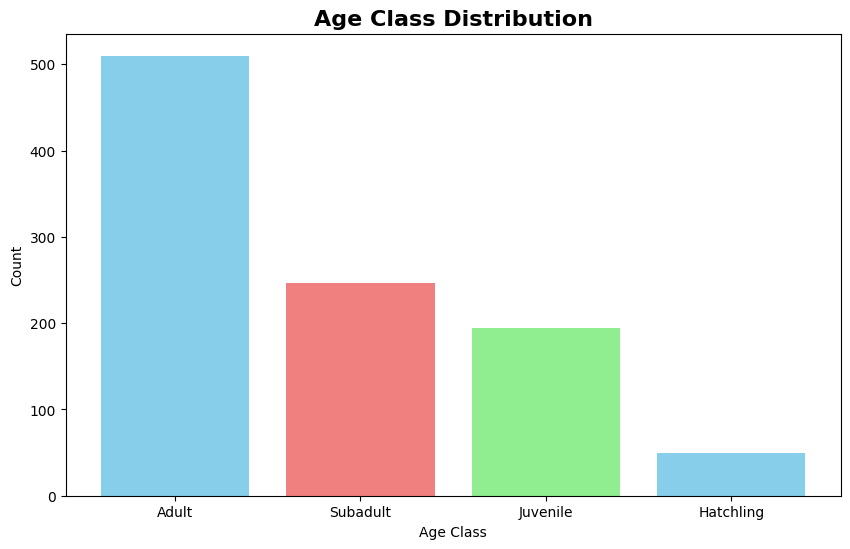

In [13]:
# 4. Age Class Distribution
plt.figure(figsize=(10, 6))
age_counts = df['Age Class'].value_counts()
plt.bar(age_counts.index, age_counts.values, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Age Class Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Age Class')
plt.ylabel('Count')
plt.show()

### 5. Sex Distribution

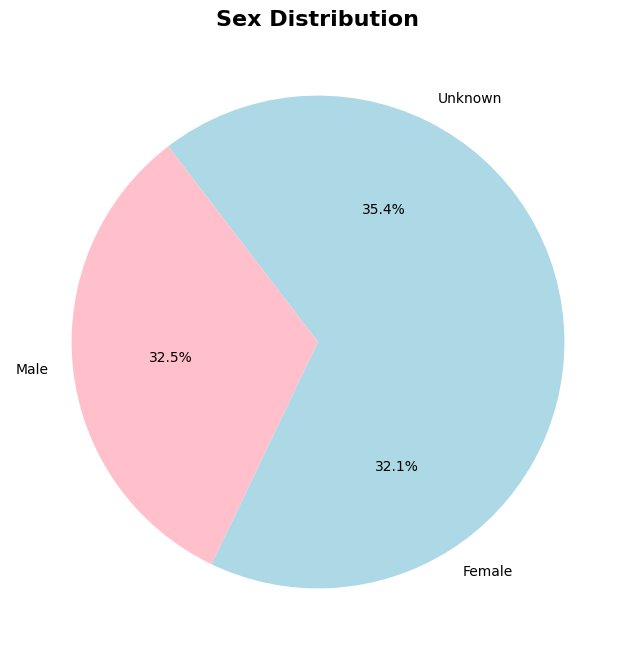

In [14]:
# 5. Sex Distribution
plt.figure(figsize=(8, 8))
sex_counts = df['Sex'].value_counts()
plt.pie(sex_counts.values, labels=sex_counts.index, autopct='%1.1f%%', colors=['lightblue', 'pink'])
plt.title('Sex Distribution', fontsize=16, fontweight='bold')
plt.show()


### 6. Habitat Type Distribution

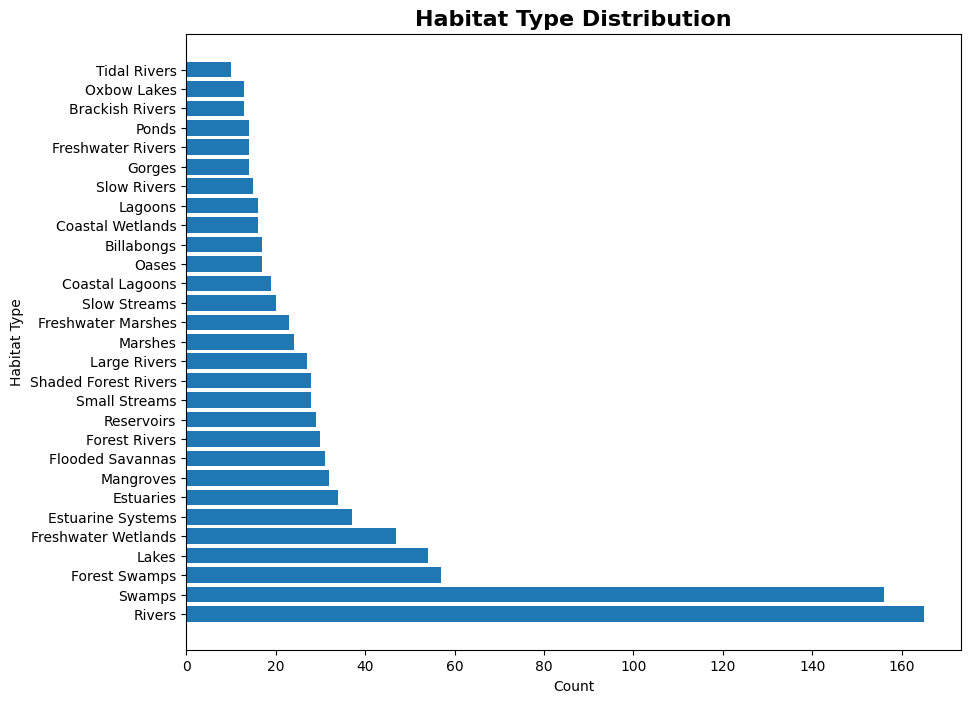

In [15]:
# 6. Habitat Type Distribution
plt.figure(figsize=(10, 8))
habitat_counts = df['Habitat Type'].value_counts()
plt.barh(range(len(habitat_counts)), habitat_counts.values)
plt.title('Habitat Type Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Habitat Type')
plt.yticks(range(len(habitat_counts)), habitat_counts.index)
plt.show()

### 7. Family Distribution

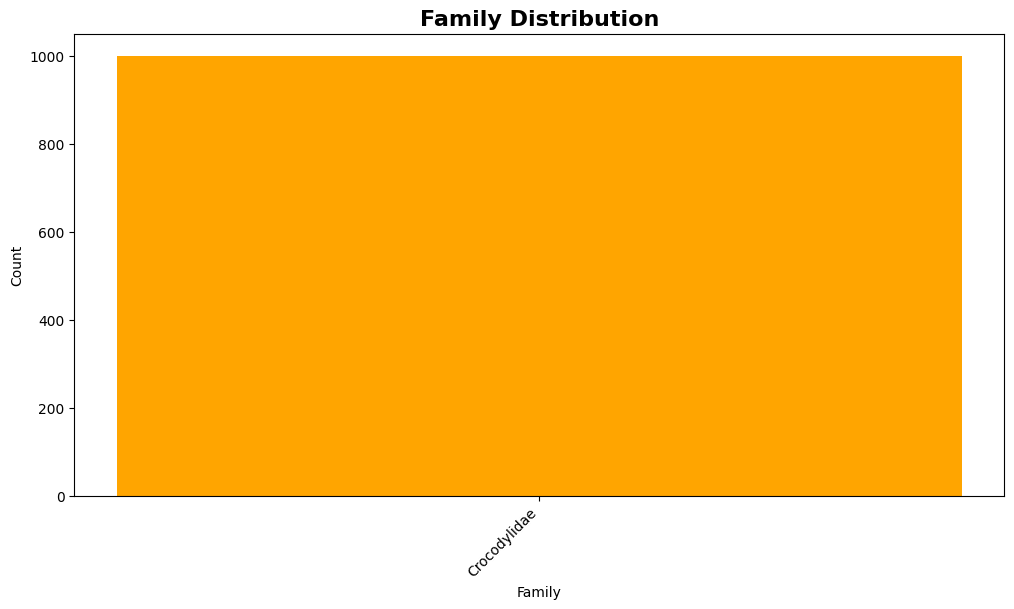

In [16]:
# 7. Family Distribution
plt.figure(figsize=(12, 6))
family_counts = df['Family'].value_counts()
plt.bar(range(len(family_counts)), family_counts.values, color='orange')
plt.title('Family Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Family')
plt.ylabel('Count')
plt.xticks(range(len(family_counts)), family_counts.index, rotation=45, ha='right')
plt.show()

### 8. Length Distribution by Age Class

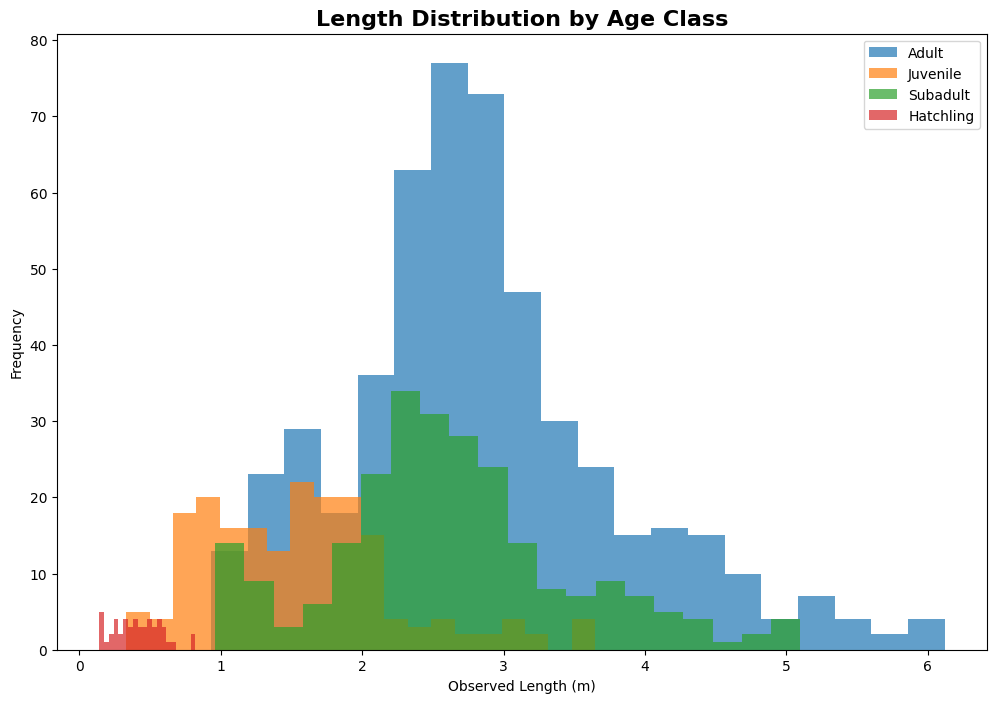

In [17]:
# 8. Length Distribution by Age Class
plt.figure(figsize=(12, 8))
for age in df['Age Class'].unique():
    age_data = df[df['Age Class'] == age]['Observed Length (m)']
    plt.hist(age_data, alpha=0.7, label=age, bins=20)
plt.xlabel('Observed Length (m)')
plt.ylabel('Frequency')
plt.title('Length Distribution by Age Class', fontsize=16, fontweight='bold')
plt.legend()
plt.show()

### 9. Weight Distribution by Sex

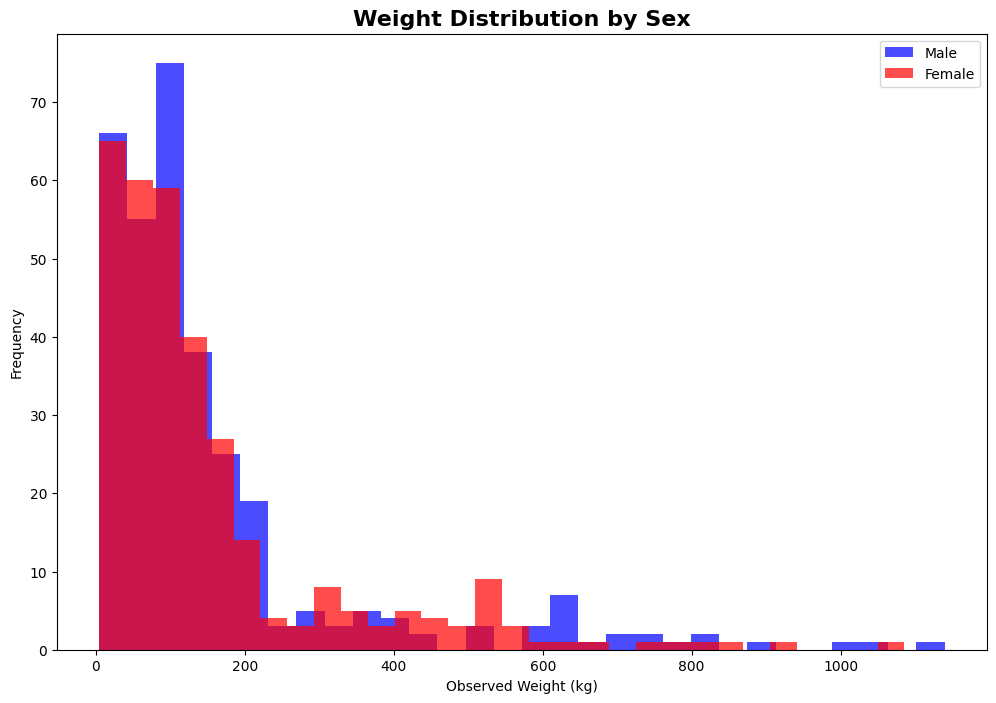

In [18]:
# 9. Weight Distribution by Sex
plt.figure(figsize=(12, 8))
male_weights = df[df['Sex'] == 'Male']['Observed Weight (kg)']
female_weights = df[df['Sex'] == 'Female']['Observed Weight (kg)']
plt.hist(male_weights, alpha=0.7, label='Male', bins=30, color='blue')
plt.hist(female_weights, alpha=0.7, label='Female', bins=30, color='red')
plt.xlabel('Observed Weight (kg)')
plt.ylabel('Frequency')
plt.title('Weight Distribution by Sex', fontsize=16, fontweight='bold')
plt.legend()
plt.show()

### 10. Observations by Country

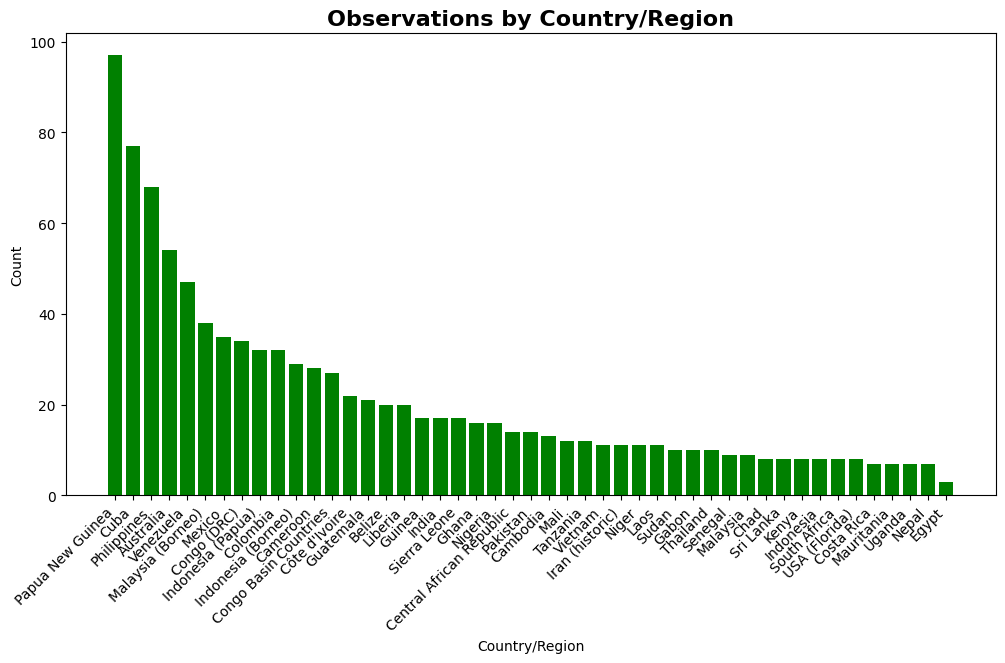

In [19]:
# 10. Observations by Country
plt.figure(figsize=(12, 6))
country_counts = df['Country/Region'].value_counts()
plt.bar(range(len(country_counts)), country_counts.values, color='green')
plt.title('Observations by Country/Region', fontsize=16, fontweight='bold')
plt.xlabel('Country/Region')
plt.ylabel('Count')
plt.xticks(range(len(country_counts)), country_counts.index, rotation=45, ha='right')
plt.show()

### 11. Conservation Status by Family

<Figure size 1400x800 with 0 Axes>

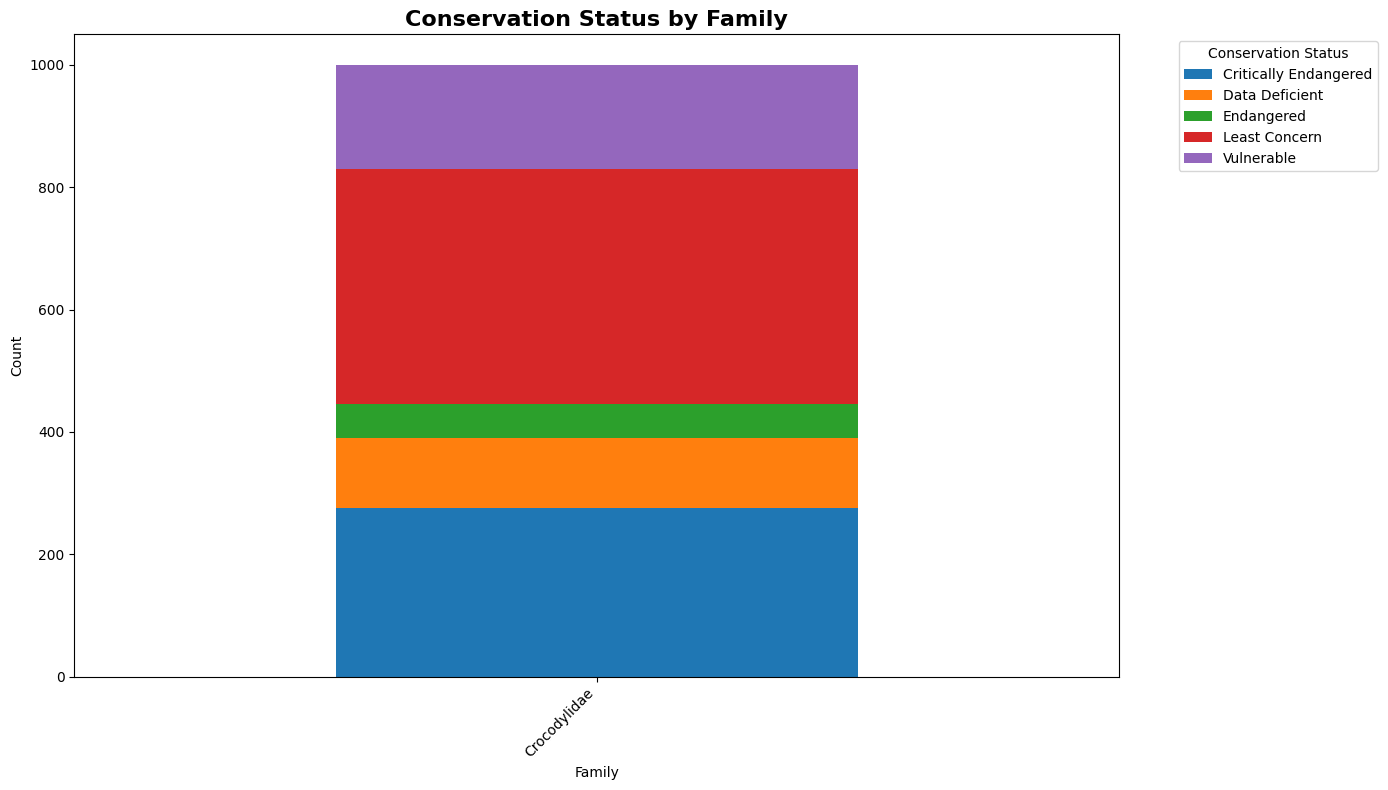

In [20]:
# 11. Conservation Status by Family
plt.figure(figsize=(14, 8))
conservation_family = pd.crosstab(df['Family'], df['Conservation Status'])
conservation_family.plot(kind='bar', stacked=True, figsize=(14, 8))
plt.title('Conservation Status by Family', fontsize=16, fontweight='bold')
plt.xlabel('Family')
plt.ylabel('Count')
plt.legend(title='Conservation Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 12. Correlation Heatmap

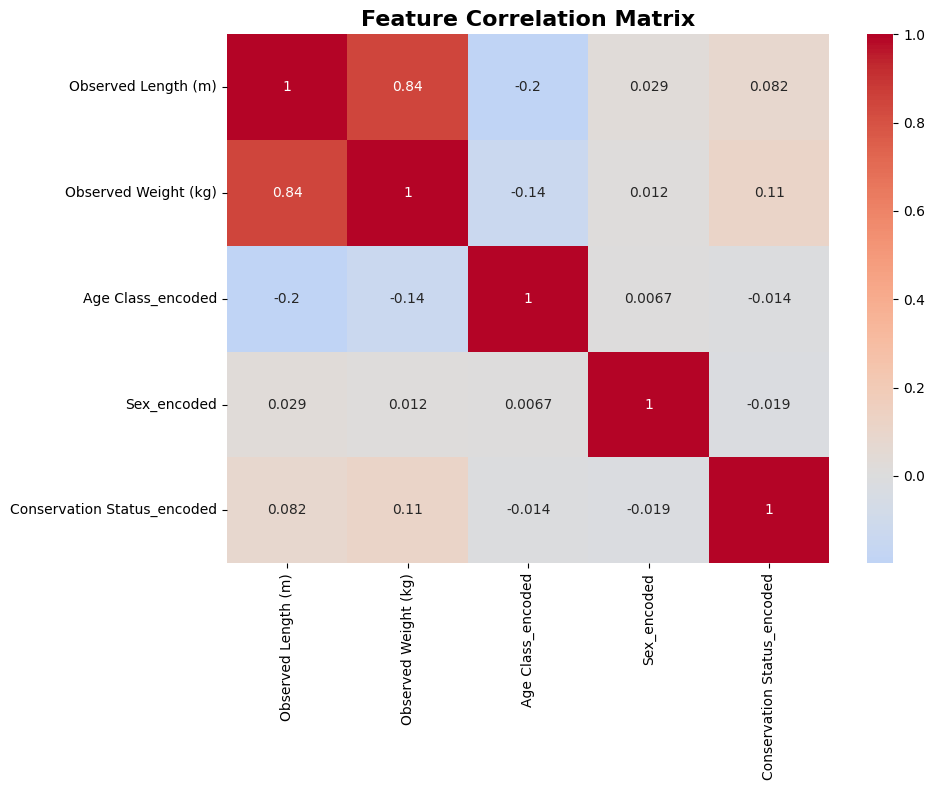

In [21]:
# 12. Correlation Heatmap
plt.figure(figsize=(10, 8))
# Prepare numerical data for correlation
corr_data = df.copy()
le = LabelEncoder()
for col in ['Age Class', 'Sex', 'Conservation Status']:
    corr_data[col + '_encoded'] = le.fit_transform(corr_data[col])

correlation_matrix = corr_data[['Observed Length (m)', 'Observed Weight (kg)', 
                               'Age Class_encoded', 'Sex_encoded', 'Conservation Status_encoded']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## Advanced Statistical Analysis

In [22]:
# Advanced Statistical Analysis
print("\n📈 Advanced Statistical Analysis:")
print("-" * 30)


📈 Advanced Statistical Analysis:
------------------------------


### Correlation analysis

In [23]:
# Correlation analysis
print("Correlation between Length and Weight:")
length_weight_corr = df['Observed Length (m)'].corr(df['Observed Weight (kg)'])
print(f"Correlation coefficient: {length_weight_corr:.4f}")

Correlation between Length and Weight:
Correlation coefficient: 0.8434


### Group statistics

In [24]:
# Group statistics
print("\nAverage measurements by Age Class:")
age_stats = df.groupby('Age Class')[['Observed Length (m)', 'Observed Weight (kg)']].mean()
print(age_stats)

print("\nAverage measurements by Sex:")
sex_stats = df.groupby('Sex')[['Observed Length (m)', 'Observed Weight (kg)']].mean()
print(sex_stats)

print("\nConservation Status by Species:")
conservation_species = pd.crosstab(df['Common Name'], df['Conservation Status'])
print(conservation_species)


Average measurements by Age Class:
           Observed Length (m)  Observed Weight (kg)
Age Class                                           
Adult                 2.835784            192.093333
Hatchling             0.414082             48.251020
Juvenile              1.546701             81.122165
Subadult              2.625547            160.738057

Average measurements by Sex:
         Observed Length (m)  Observed Weight (kg)
Sex                                               
Female              2.378318            152.540187
Male                2.407077            156.731385
Unknown             2.455847            157.821469

Conservation Status by Species:
Conservation Status                        Critically Endangered  \
Common Name                                                        
American Crocodile                                             0   
Borneo Crocodile (disputed)                                    0   
Central African Slender-snouted Crocodile               

## PREDICTIVE MODELING 

In [25]:
# ============================================================================
# PREDICTIVE MODELING 
# ============================================================================

print("\n" + "="*50)
print("🤖 PHASE 3: PREDICTIVE MODELING")
print("="*50)

# Prepare data for modeling
print("Preparing data for modeling...")

# Feature engineering
df_model = df.copy()

# Label encoding for categorical variables
label_encoders = {}
categorical_features = ['Age Class', 'Sex', 'Family', 'Habitat Type']

for feature in categorical_features:
    le = LabelEncoder()
    df_model[feature + '_encoded'] = le.fit_transform(df_model[feature])
    label_encoders[feature] = le

# Create additional features
df_model['Length_Weight_Ratio'] = df_model['Observed Length (m)'] / (df_model['Observed Weight (kg)'] + 1)  # +1 to avoid division by zero
df_model['Size_Category'] = pd.cut(df_model['Observed Weight (kg)'], 
                                   bins=[0, 50, 200, 1000, np.inf], 
                                   labels=['Small', 'Medium', 'Large', 'Very Large'])
df_model['Size_Category_encoded'] = LabelEncoder().fit_transform(df_model['Size_Category'])

print("✅ Feature engineering completed!")



🤖 PHASE 3: PREDICTIVE MODELING
Preparing data for modeling...
✅ Feature engineering completed!


## CONSERVATION STATUS CLASSIFICATION


🎯 Model 1: Conservation Status Classification
----------------------------------------
🎯 Classification Accuracy: 0.7550

Classification Report:
                       precision    recall  f1-score   support

Critically Endangered       0.80      0.65      0.71        54
       Data Deficient       0.69      0.69      0.69        16
           Endangered       1.00      0.64      0.78        11
        Least Concern       0.74      0.84      0.78        80
           Vulnerable       0.74      0.79      0.77        39

             accuracy                           0.76       200
            macro avg       0.79      0.72      0.75       200
         weighted avg       0.76      0.76      0.75       200


Feature Importance:
                 feature  importance
5   Habitat Type_encoded    0.270793
6    Length_Weight_Ratio    0.249802
1   Observed Weight (kg)    0.210608
0    Observed Length (m)    0.170928
3            Sex_encoded    0.037949
2      Age Class_encoded    0.036100
7  S

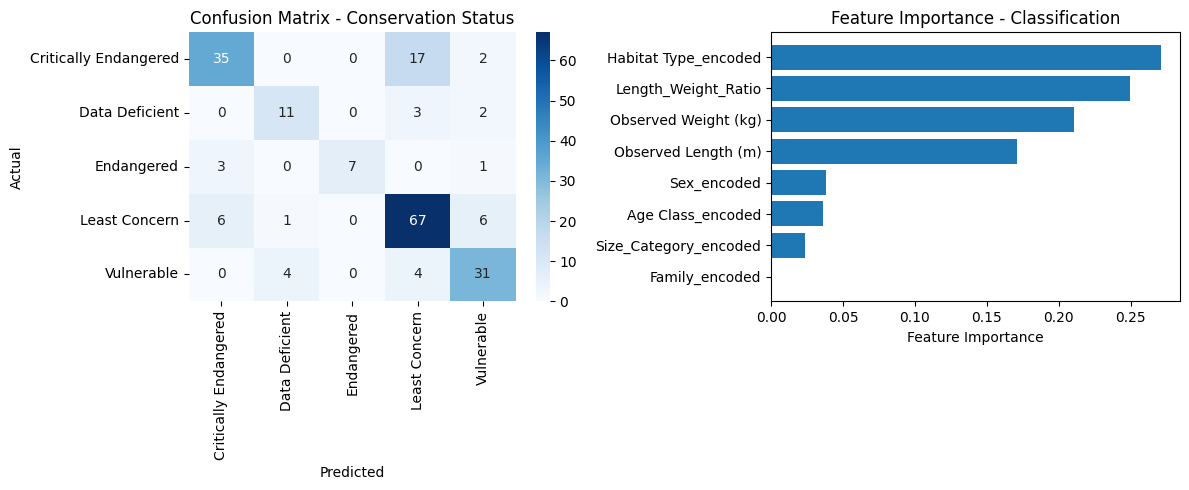

In [26]:
# ============================================================================
# CONSERVATION STATUS CLASSIFICATION
# ============================================================================

print("\n🎯 Model 1: Conservation Status Classification")
print("-" * 40)

# Prepare features and target
feature_cols = ['Observed Length (m)', 'Observed Weight (kg)', 'Age Class_encoded', 
               'Sex_encoded', 'Family_encoded', 'Habitat Type_encoded', 
               'Length_Weight_Ratio', 'Size_Category_encoded']

X = df_model[feature_cols]
y = LabelEncoder().fit_transform(df_model['Conservation Status'])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Classification Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
conservation_labels = LabelEncoder().fit(df_model['Conservation Status']).classes_
print(classification_report(y_test, y_pred, target_names=conservation_labels))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# Confusion Matrix
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=conservation_labels, 
            yticklabels=conservation_labels)
plt.title('Confusion Matrix - Conservation Status')
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Feature Importance Plot
plt.subplot(1, 2, 2)
plt.barh(range(len(feature_importance)), feature_importance['importance'])
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance - Classification')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


## WEIGHT PREDICTION (REGRESSION)


📊 Model 2: Weight Prediction (Regression)
----------------------------------------
Linear Regression Results:
  MSE: 8306.85
  R² Score: 0.6746

Random Forest Regression Results:
  MSE: 1306.08
  R² Score: 0.9488


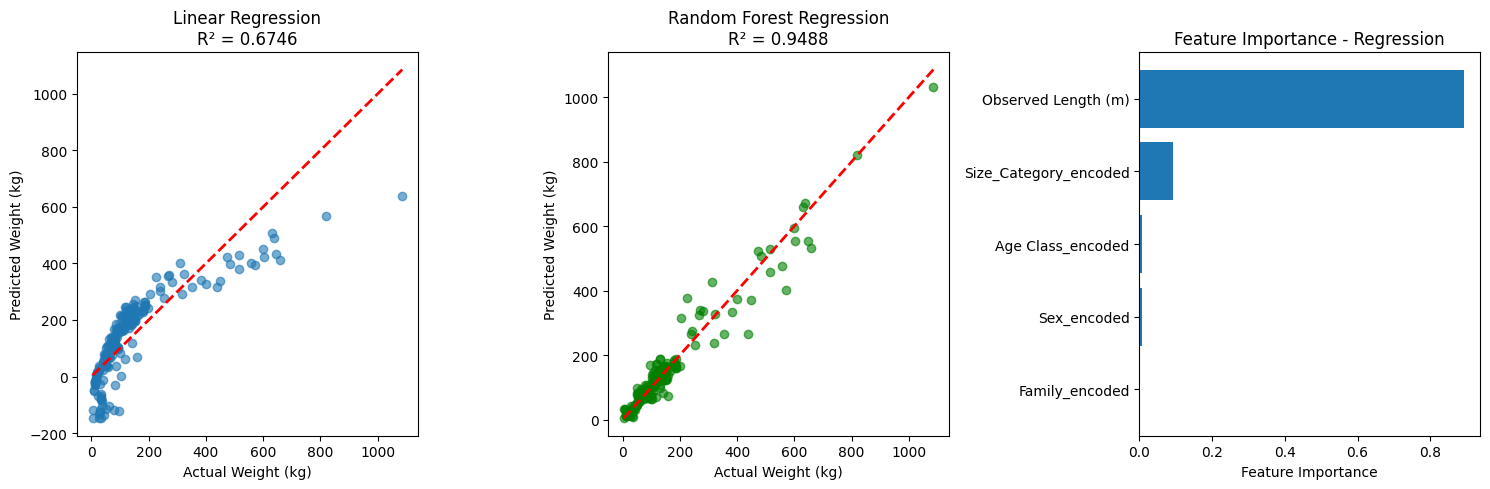

In [27]:
# ============================================================================
#  WEIGHT PREDICTION (REGRESSION)
# ============================================================================

print("\n📊 Model 2: Weight Prediction (Regression)")
print("-" * 40)

# Prepare features for weight prediction
regression_features = ['Observed Length (m)', 'Age Class_encoded', 'Sex_encoded', 
                      'Family_encoded', 'Size_Category_encoded']

X_reg = df_model[regression_features]
y_reg = df_model['Observed Weight (kg)']

# Split the data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Train Linear Regression and Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

lr_regressor = LinearRegression()
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

lr_regressor.fit(X_train_reg, y_train_reg)
rf_regressor.fit(X_train_reg, y_train_reg)

# Make predictions
y_pred_lr = lr_regressor.predict(X_test_reg)
y_pred_rf = rf_regressor.predict(X_test_reg)

# Evaluate models
lr_mse = mean_squared_error(y_test_reg, y_pred_lr)
lr_r2 = r2_score(y_test_reg, y_pred_lr)

rf_mse = mean_squared_error(y_test_reg, y_pred_rf)
rf_r2 = r2_score(y_test_reg, y_pred_rf)

print("Linear Regression Results:")
print(f"  MSE: {lr_mse:.2f}")
print(f"  R² Score: {lr_r2:.4f}")

print("\nRandom Forest Regression Results:")
print(f"  MSE: {rf_mse:.2f}")
print(f"  R² Score: {rf_r2:.4f}")

# Visualize regression results
plt.figure(figsize=(15, 5))

# Linear Regression predictions
plt.subplot(1, 3, 1)
plt.scatter(y_test_reg, y_pred_lr, alpha=0.6)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Weight (kg)')
plt.ylabel('Predicted Weight (kg)')
plt.title(f'Linear Regression\nR² = {lr_r2:.4f}')

# Random Forest predictions
plt.subplot(1, 3, 2)
plt.scatter(y_test_reg, y_pred_rf, alpha=0.6, color='green')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Weight (kg)')
plt.ylabel('Predicted Weight (kg)')
plt.title(f'Random Forest Regression\nR² = {rf_r2:.4f}')

# Feature importance for regression
plt.subplot(1, 3, 3)
reg_importance = pd.DataFrame({
    'feature': regression_features,
    'importance': rf_regressor.feature_importances_
}).sort_values('importance', ascending=False)

plt.barh(range(len(reg_importance)), reg_importance['importance'])
plt.yticks(range(len(reg_importance)), reg_importance['feature'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance - Regression')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


## ADVANCED INSIGHTS AND CONCLUSIONS

In [28]:
# ============================================================================
# ADVANCED INSIGHTS AND CONCLUSIONS
# ============================================================================

print("\n" + "="*50)
print("💡 ADVANCED INSIGHTS AND CONCLUSIONS")
print("="*50)

print("🔍 Key Findings:")
print("-" * 20)

# Species insights
largest_species = df.loc[df['Observed Weight (kg)'].idxmax(), 'Common Name']
smallest_species = df.loc[df['Observed Weight (kg)'].idxmin(), 'Common Name']
print(f"• Largest observed species: {largest_species}")
print(f"• Smallest observed species: {smallest_species}")

# Conservation insights
endangered_species = df[df['Conservation Status'].isin(['Critically Endangered', 'Endangered'])]['Common Name'].unique()
print(f"• Number of endangered species in dataset: {len(endangered_species)}")
print(f"• Endangered species: {', '.join(endangered_species)}")

# Size relationships
print(f"• Length-Weight correlation: {length_weight_corr:.3f} (Strong positive correlation)")

# Model performance
print(f"• Conservation status prediction accuracy: {accuracy:.1%}")
print(f"• Weight prediction R² score: {max(lr_r2, rf_r2):.3f}")

# Habitat analysis
most_common_habitat = df['Habitat Type'].mode()[0]
print(f"• Most common habitat: {most_common_habitat}")

print("\n🎯 Model Performance Summary:")
print("-" * 30)
print(f"Classification Model (Conservation Status):")
print(f"  - Algorithm: Random Forest")
print(f"  - Accuracy: {accuracy:.1%}")
print(f"  - Best performing features: {', '.join(feature_importance.head(3)['feature'].tolist())}")

print(f"\nRegression Model (Weight Prediction):")
print(f"  - Best Algorithm: {'Random Forest' if rf_r2 > lr_r2 else 'Linear Regression'}")
print(f"  - R² Score: {max(lr_r2, rf_r2):.3f}")
print(f"  - MSE: {min(lr_mse, rf_mse):.2f}")

print("\n📊 Data Quality Assessment:")
print("-" * 30)
print(f"• Dataset completeness: 100% (no missing values)")
print(f"• Species diversity: {df['Common Name'].nunique()} different species")
print(f"• Geographic coverage: {df['Country/Region'].nunique()} countries/regions")
print(f"• Temporal coverage: {df['Date of Observation'].nunique()} unique observation dates")
print(f"• Observer diversity: {df['Observer Name'].nunique()} different observers")

print("\n✨ Recommendations:")
print("-" * 20)
print("• The dataset shows strong predictive potential for conservation status")
print("• Length and weight measurements are highly correlated and reliable")
print("• Family and habitat type are strong predictors for conservation status")
print("• Consider collecting more environmental data for improved predictions")
print("• The model could be enhanced with additional features like population size, range area, etc.")

print("\n🏁 Analysis Complete!")
print("="*50)


💡 ADVANCED INSIGHTS AND CONCLUSIONS
🔍 Key Findings:
--------------------
• Largest observed species: Saltwater Crocodile
• Smallest observed species: West African Dwarf Crocodile
• Number of endangered species in dataset: 6
• Endangered species: Orinoco Crocodile, Siamese Crocodile, Cuban Crocodile, Philippine Crocodile, West African Slender-snouted Crocodile, Central African Slender-snouted Crocodile
• Length-Weight correlation: 0.843 (Strong positive correlation)
• Conservation status prediction accuracy: 75.5%
• Weight prediction R² score: 0.949
• Most common habitat: Rivers

🎯 Model Performance Summary:
------------------------------
Classification Model (Conservation Status):
  - Algorithm: Random Forest
  - Accuracy: 75.5%
  - Best performing features: Habitat Type_encoded, Length_Weight_Ratio, Observed Weight (kg)

Regression Model (Weight Prediction):
  - Best Algorithm: Random Forest
  - R² Score: 0.949
  - MSE: 1306.08

📊 Data Quality Assessment:
----------------------------